In [ ]:
!uv pip list

In [3]:
# !uv pip show tensorflow
!uv pip install tensorflow

Resolved 32 packages in 1.19s
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 22 packages in 3m 37s
 + absl-py==2.4.0
 + astunparse==1.6.3
 + flatbuffers==25.12.19
 + gast==0.7.0
 + google-pasta==0.2.0
 + grpcio==1.81.0
 + h5py==3.14.0
 + keras==3.14.1
 + libclang==18.1.1
 + markdown-it-py==4.2.0
 + mdurl==0.1.2
 + ml-dtypes==0.5.4
 + namex==0.1.0
 + numpy==2.4.6
 + opt-einsum==3.4.0
 + optree==0.19.1
 + protobuf==7.35.0
 + rich==15.0.0
 + tensorflow==2.21.0
 + termcolor==3.3.0
 + wheel==0.47.0
 + wrapt==2.2.1


In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

import numpy as np

# 加载mnist数据集
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = mnist.load_data()

# 查看数据形状
print("="*50)
print("MNIST 数据集基本信息")
print("="*50)
print(x_train_raw.shape)
print(f"训练集样本数量：{x_train_raw.shape[0]}")
print(f"测试集样本数量：{y_train_raw.shape[0]}")
print(f"图片原始尺寸:{x_train_raw.shape[1]} x {x_train_raw.shape[2]} 像素")
print(f"像素值范围：{x_train_raw.min()} ~ {x_train_raw.max()}")
print(f"标签范围：{y_train_raw.min()} ~ {y_train_raw.max()}")
print()

In [ ]:
# 数据归一化 将像素值从 0- 255 缩放到 0-1
x_train = x_train_raw.astype('float32') / 255.0
x_test = x_test_raw.astype('float32') / 255.0
# print(x_train)
# print(x_test)


In [14]:
# 数据转换 有两种方法

# 方法一：将28*28图像展平成784维向量 (适合于全连接网络)
# 方法二：保留二维结构并增加通道维度(28, 28, 1) (适用于卷积神经网络) (CNN常见)

# 增加通道维度(样本数， 28， 28， 1)
x_train_add_axis = x_train[..., np.newaxis] # np.newaxis 插入一个长度为1的新轴(新维度)
x_test_add_axis = x_test[..., np.newaxis]

# 标签转换：将整数标签转为 one-hot编码 (用于分类交叉熵损失)
y_train_convert = to_categorical(y_train_raw, 10)
y_test_convert = to_categorical(y_test_raw, 10)

print("预处理后数据形状")
print(f"训练集图像：{x_train_add_axis.shape} (样本数， 高度， 宽度， 通道)")
print(f"训练集标签：{y_train_convert.shape} (one-hot)")
print(f"测试集图像：{x_test_add_axis.shape}")
print(f"测试集标签：{y_test_convert.shape}")
print(f"像素值范围检验:{x_train.min():.2f} ~ {x_train.max():.2f}")

预处理后数据形状
训练集图像：(60000, 28, 28, 1) (样本数， 高度， 宽度， 通道)
训练集标签：(60000, 10) (one-hot)
测试集图像：(10000, 28, 28, 1)
测试集标签：(10000, 10)
像素值范围检验:0.00 ~ 1.00


In [10]:
!uv pip show matplotlib

In [11]:
!uv pip install matplotlib

Resolved 11 packages in 2.98s
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 7 packages in 11.13s
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.63.0
 + kiwisolver==1.5.0
 + matplotlib==3.10.9
 + pillow==12.2.0
 + pyparsing==3.3.2


d:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8978 - loss: 0.3649 - val_accuracy: 0.9582 - val_loss: 0.1506
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9578 - loss: 0.1451 - val_accuracy: 0.9710 - val_loss: 0.1077
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9703 - loss: 0.1014 - val_accuracy: 0.9723 - val_loss: 0.0990
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9767 - loss: 0.0771 - val_accuracy: 0.9762 - val_loss: 0.0845
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9816 - loss: 0.0598 - val_accuracy: 0.9772 - val_loss: 0.0812
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9853 - loss: 0.0492 - val_accuracy: 0.9768 - val_loss: 0.0828
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9877 - loss: 0.0403 - val_accuracy: 0.9782 - val_loss: 0.0804
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9903 - loss: 0.0324 - val_accuracy: 0.

测试集损失率：0.08020889759063721 ,测试集准确率：0.9778000116348267


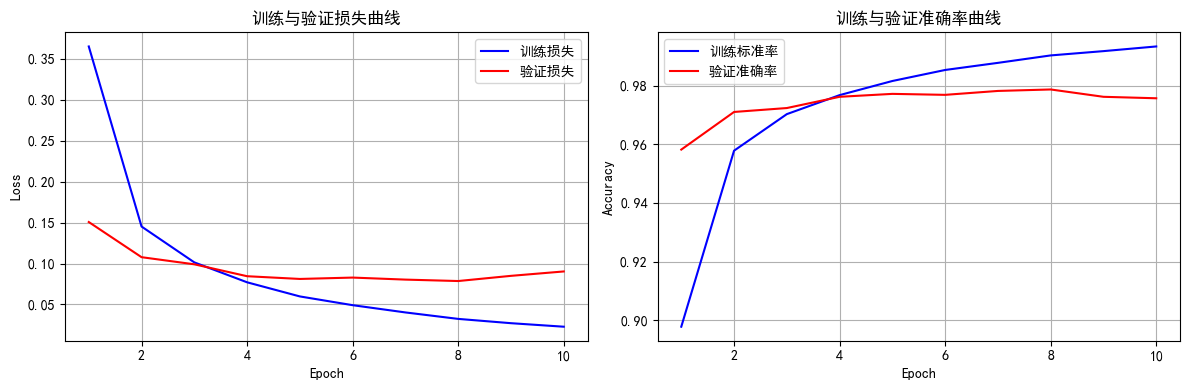

In [ ]:
"""
    # 任务二 神经网络模型构建与训练任务
    使用Keras框架构建一个全连接神经网络模型，用于手写数字识别。
    模型至少包含输入层，隐藏层和输出层
    编写训练代码，设置合适的优化器，损失函数和评估指标
    训练完成后保存模型到本地(如 model.h5)
    绘制包含损失和准确率变化曲线
"""
# 导入 Sequential 模型类，它是 Keras中最简单的模型类型。适合大多数前馈神经网络
from tensorflow.keras.models import Sequential
# 导入 常用的网络层 Dense 全连接层，Flatten 展平层
# 全连接层，每个输入节点都与该层的所有输出节点相连
# 展平层，将多维输入(二维图像，三维特征图)"压平"一堆向量
from tensorflow.keras.layers import Dense, Flatten
# 导入 Adam 优化器
# Adam是一种基于梯度的优化算法，自动调节每个参数的学习率，训练速度快，收敛稳定，深度学习中最常用的优化器之一
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt

# relu softmax 都属于 激活函数
# relu 常见用途 隐藏层(默认首选)：只留正数，负数砍掉 -> 让网络简单稀疏
# softmax 多酚类输出层：把一堆分数变成概率 -> 多分类投票器
# 激活函数：神经元的"开关/阀门"，给网络加入非线性能力

model = Sequential([
    Flatten(input_shape=(28, 28)), # 输入层：将28*28图像展平成784维
    Dense(128, activation= 'relu'), # 隐藏层1: 128个神经元
    Dense(64, activation= 'relu'), # 隐藏层2：64个神经元
    Dense(10, activation= 'softmax') # 输出层：10个类别
])


# 显示模型结构
model.summary()

# 编译模型
# 实际上做的是配置优化器，损失和指标。可以理解为"设置学习任务"
# optimizer : 优化器，负责调整神经网络重的参数（权重与偏置），让模型一步步减少错误
# Adam ： 一种常用优化算法，learning_rate=0.001 控制每次更新的幅度

# loss ：损失函数，计算模型预测值与真实标签之间的差距。数值越小，说明预测越准
# categorical_crossentropy ：分类交叉熵，抓门用于多分类。 要求标签必须是 one-hot编码

# metrics: 评价指标（监控用）
# accuracy ：准确率 预测正确的样本数/总样本数。比如 accuracy precision recall ，但训练时一般用准确率就够了

# 三部分配置好，行程学习规则，编译完成后，模型就知道：
# 要用Adam方法，以0.001的学习率，以交叉熵作为模型的错误惩罚标准，并且在每一轮训练后告诉模型准确率是多少
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 训练模型
# model.fit 启动前面定义好的神经网络
# x_train_add_axis, y_train_add_axis 训练数据和对应标签
# batch_size 每次同时处理 128张图片
# epochs 把整个训练数据集完整学10遍
# validation_split 从训练数据中切出10%作为验证集
# verbose 控制打印日志的详细程度 1 打印进度条 0 什么都不打 2 只打印每一轮结果
history = model.fit(
    x_train_add_axis,
    y_train_convert,
    batch_size = 128,
    epochs = 10,
    validation_split = 0.1,
    verbose = 1
)

# 训练后用从未见过的测试集来评估模型的最终表现
test_loss, test_accuracy = model.evaluate(x_test_add_axis, y_test_convert, verbose=0)
print(f"测试集损失率：{test_loss} ,测试集准确率：{test_accuracy}")

# 保存模型
model.save('model.h5') # 保存为HDF5格式


# 绘制训练过程中的损失和准确率曲线
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 4))


# 损失曲线
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, 'b-', label='训练损失')
plt.plot(epochs_range, val_loss, 'r-', label='验证损失')
plt.title('训练与验证损失曲线')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 准确率曲线
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, 'b-', label= '训练标准率')
plt.plot(epochs_range, val_acc, 'r-', label= '验证准确率')
plt.title('训练与验证准确率曲线')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


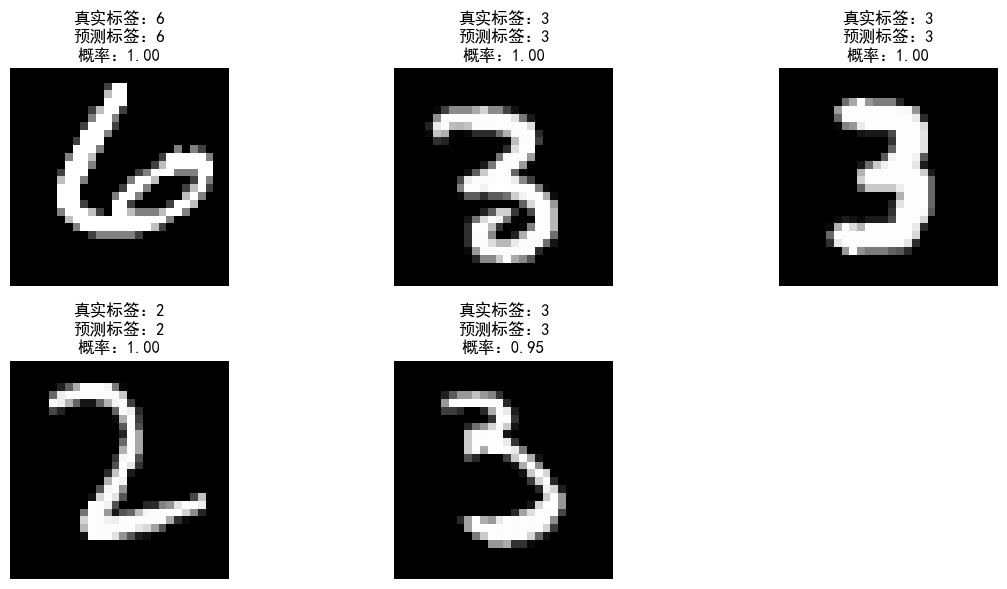

In [21]:
"""
    任务三：
        加载已保存模型
        对测试集中图片进行预测，随机选中5张测试图片，展示每张图片以及真实标签和预测结果。
        将测试图片，预测结果和预测概率可视化展示
"""

from tensorflow.keras.models import load_model

local_model = load_model('model.h5')

# 加载MNIST测试集
(_, _), (test_data, test_label) = mnist.load_data()

# 对训练集进行与训练时相同的预处理
test_data = test_data.astype('float32') / 255.0

# 随机选择5张测试图片
num_samples = 5
indices = np.random.choice(len(test_data), num_samples, replace=False)
sample_images = test_data[indices]
sample_labels = test_label[indices]

# 对选中图片进行预测
predictions = model.predict(sample_images)
predicted_classes = np.argmax(predictions, axis=1) # 预测类别
predicted_probs = np.max(predictions, axis=1) # 最大概率值

# 使用matplotlib 可视化结果
plt.figure(figsize=(12, 6))
for i in range(num_samples):
    plt.subplot(2, 3, i + 1)
    plt.imshow(sample_images[i], cmap='gray')
    plt.title(f"真实标签：{sample_labels[i]}\n预测标签：{predicted_classes[i]}\n概率：{predicted_probs[i]:.2f}")
    plt.axis('off')
plt.tight_layout()
plt.show()